In [1]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader

!pip install denoising_diffusion_pytorch

from denoising_diffusion_pytorch import Unet, GaussianDiffusion



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 9.4 MB/s eta 0:00:00


In [2]:


# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 10
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250



In [3]:

# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



loading MNIST digits dataset


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


In [4]:

DIM = 32
DIM_MULTS = (1, 2, 5)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
)

optim = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)


In [6]:


from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
diffusion = diffusion.to(device)

train_losses = []

for epoch in range(N_EPOCHS):

    model.train()

    running_loss = 0.0

    loop = tqdm(loader, leave=False)

    for batch_idx, (images, labels) in enumerate(loop):

        # normalize between 0 and 1
        images = images.to(device).float()

        # DDPM loss
        loss = diffusion(images)

        optim.zero_grad()
        loss.backward()
        optim.step()

        running_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{N_EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}: loss = {epoch_loss:.5f}")



  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: loss = 0.10264


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: loss = 0.05238


  0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8: loss = 0.03953


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9: loss = 0.03909


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10: loss = 0.03854


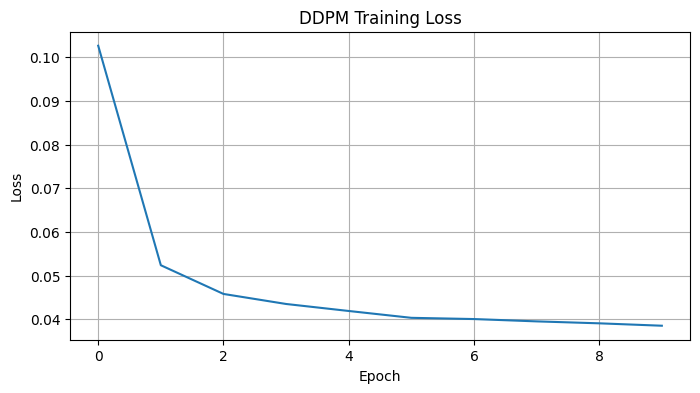

In [7]:
import matplotlib.pyplot as plt

# Plot training curve
plt.figure(figsize=(8,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Training Loss")
plt.grid(True)
plt.show()




sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

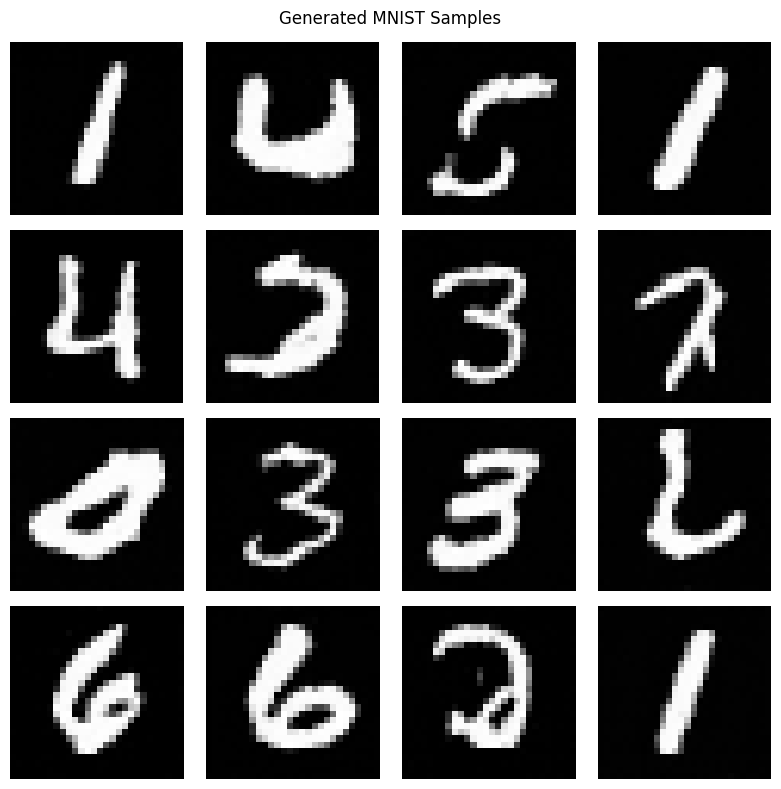

In [9]:
# Generate MNIST samples


model.eval()

with torch.no_grad():

    sampled_images = diffusion.sample(batch_size = 16)

# sampled_images are already normalized to [0,1]
sampled_images = sampled_images.cpu()

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    img = sampled_images[i].squeeze().numpy()

    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.axis("off")

plt.suptitle("Generated MNIST Samples")
plt.tight_layout()
plt.show()

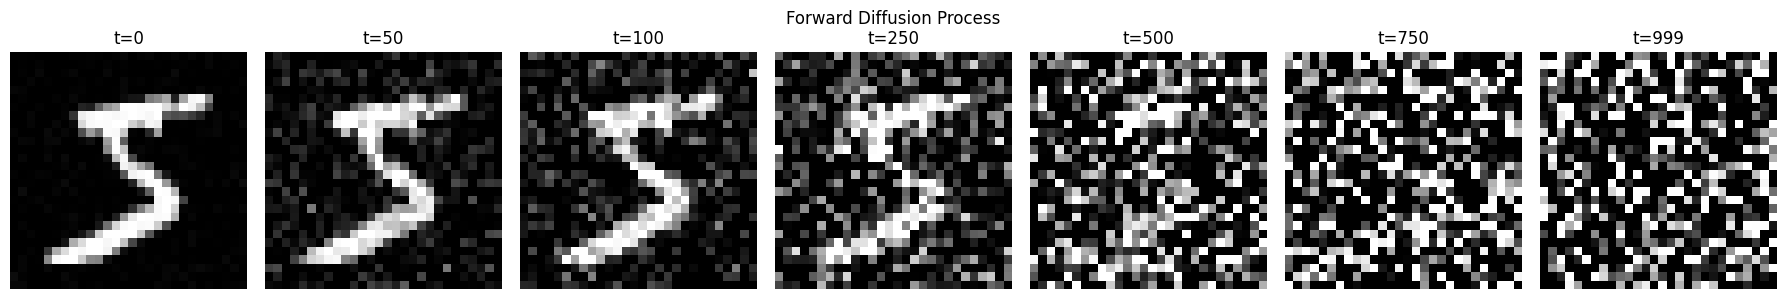

In [10]:
# Visualize diffusion at different timesteps


example_img, _ = dataset[0]
example_img = example_img.unsqueeze(0).to(device)

timesteps_to_show = [0, 50, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(18,3))

for idx, t in enumerate(timesteps_to_show):

    t_tensor = torch.tensor([t], device=device)

    noisy_img = diffusion.q_sample(
        x_start = example_img,
        t = t_tensor
    )

    noisy_img = noisy_img.squeeze().detach().cpu().numpy()

    axes[idx].imshow(noisy_img, cmap='gray', vmin=0, vmax=1)
    axes[idx].set_title(f"t={t}")
    axes[idx].axis("off")

plt.suptitle("Forward Diffusion Process")
plt.tight_layout()
plt.show()